In [38]:
import Ab as ab
import datetime as dt
import pandas as pd
sd = dt.datetime(2016,1,22)
ed = dt.datetime(2025,7,18)


tqqq = ab.StockData('TQQQ')
tqqq.get_data_from_yfinance('TQQQ',sd,ed+dt.timedelta(days=1))

ffty = ab.StockData('FFTY')
ffty.get_data_from_yfinance('FFTY',sd,ed+dt.timedelta(days=1))

naa200r = ab.StockData('NAA200R')
naa200r.get_data_from_csv('data/NAA200R.csv')

ticker = tqqq

#set max number of rows to display
pd.set_option('display.max_rows', 1000)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [39]:
test_start = sd
test_end =   ed


In [40]:
#buy and hold
bah = ab.BuyAndHold(ticker)
bah.run_strategy(ticker,test_start,test_end)
bah.trades

,Signal
Date,
2016-01-22,1
2025-07-18,-1


/home/zishuowang/backtesting/Ab.py:779: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.28016354112805275' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.balance.loc[i[0], 'Stock'] = p_stock + p_cash / c_price
/home/zishuowang/backtesting/Ab.py:781: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.9999999999999999' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.balance.loc[i[0], 'Total'] = self.balance.loc[i[0],'Cash'] + self.balance.loc[i[0], 'Stock'] * c_price
/home/zishuowang/backtesting/Ab.py:782: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.9999999999999999' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.balance.loc[i[0], 'Buy P


<Ab.StockData object at 0x7f2d54eb83d0>:
cumulative return      : 2330.42%
compound anual return  : 42.5491%
max_drawdown           : -81.02%
sharp_ratio            : 5.31%
average of daily return: 0.2235%
std of daily return    : 4.2073%
number of trades       : 2,
trading days           : 3465,
batting Average        : 100.00%
Gain Average           : 2330.42%
Loss Average           : nan%
Risk Reward Ratio      : nan
Gain STD               : nan%
Loss STD               : nan%
        
    Buy Date            Sell Date Ticker     Quant  Buy Price  Sell Price  \
0 2016-01-22  2025-07-18 00:00:00   TQQQ  0.280164   3.569344       86.75   

      Profit   Profit %  HoldingDays  LongTermProfit  ShortTermProfit  \
0  23.304187  23.304187       3465.0       23.304187              0.0   

   TaxCollectYear  TaxCollected  
0          2026.0           0.0  


/home/zishuowang/backtesting/Ab.py:795: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '24.304187192858578' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.balance.loc[i[0], 'Cash'] = p_cash + p_stock * sell_price
/home/zishuowang/backtesting/Ab.py:693: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2025-07-18 00:00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  self.trade_records.loc[i, 'Sell Date'] = pd.to_datetime(date)


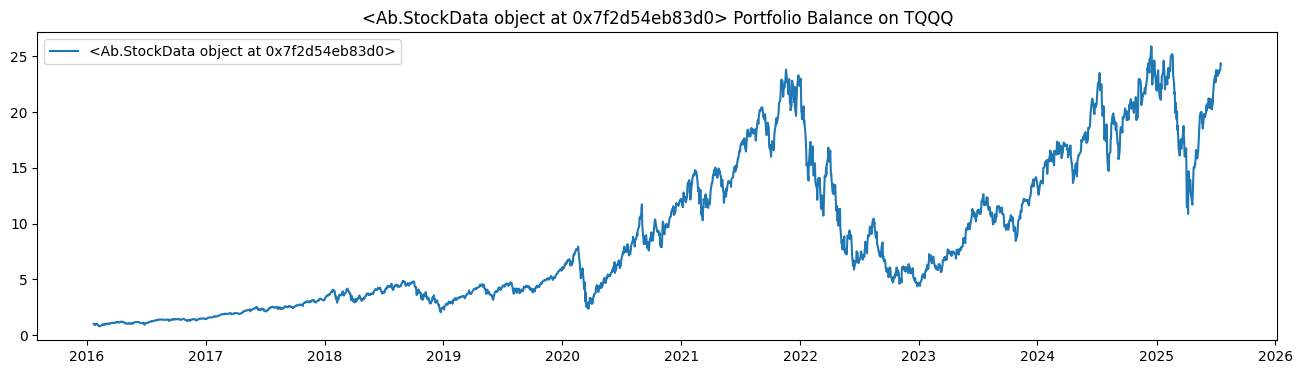

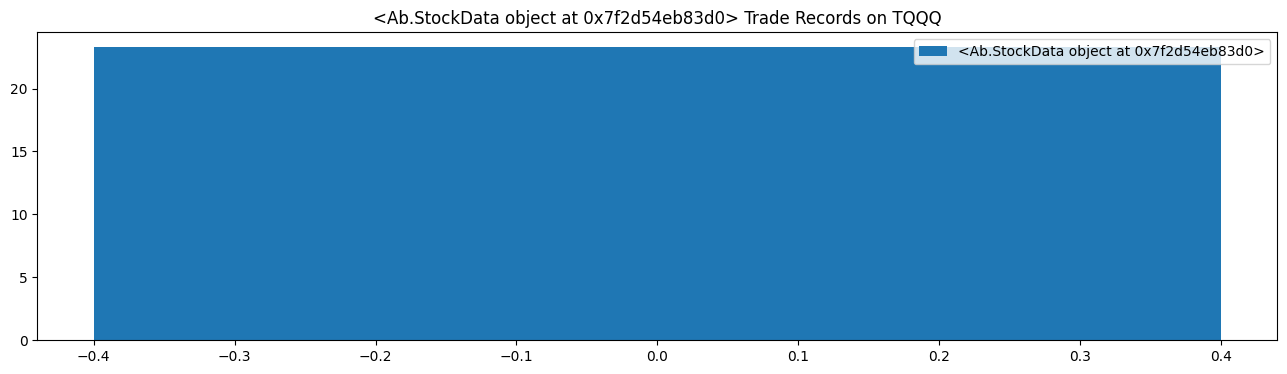

In [41]:
bah_bt = ab.BackTest()
print(ticker)
bah_bt.run_backtest(bah,ticker,test_start,test_end)
bah_bt.plot_balance()
bah_bt.plot_records()
bah_bt.performance_summary()
print(bah_bt.trade_records)

/home/zishuowang/backtesting/Ab.py:779: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.208261120854196' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.balance.loc[i[0], 'Stock'] = p_stock + p_cash / c_price
/home/zishuowang/backtesting/Ab.py:707: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.019601144806958' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.balance.loc[i[0], 'Total'] = total
/home/zishuowang/backtesting/Ab.py:795: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2.4378737653701856' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.balance.loc[i[0], 'Cash'] = p_cash + p_stock * sell_price
/home/zishuowang/backtesting/Ab.py:69


fftynaa200r_stg:
cumulative return      : 3360.43%
compound anual return  : 48.2568%
max_drawdown           : -63.33%
sharp_ratio            : 6.22%
average of daily return: 0.2019%
std of daily return    : 3.2448%
number of trades       : 23,
trading days           : 3465,
batting Average        : 45.45%
Gain Average           : 89.60%
Loss Average           : -10.42%
Risk Reward Ratio      : 8.60
Gain STD               : 140.28%
Loss STD               : 5.32%
        
     Buy Date            Sell Date Ticker     Quant  Buy Price  Sell Price  \
0  2016-11-07  2018-10-24 00:00:00   TQQQ  0.208261   4.801664   11.705852   
1  2018-11-01  2018-11-12 00:00:00   TQQQ  0.186973  13.038671   11.703458   
2  2018-11-28  2018-12-04 00:00:00   TQQQ  0.182495  11.990601   11.349319   
3  2019-01-04  2020-03-09 00:00:00   TQQQ  0.225871   9.169830   14.681763   
4  2020-04-08  2021-12-01 00:00:00   TQQQ  0.253902  13.060846   74.379936   
5  2021-12-08  2021-12-09 00:00:00   TQQQ  0.231962  81.

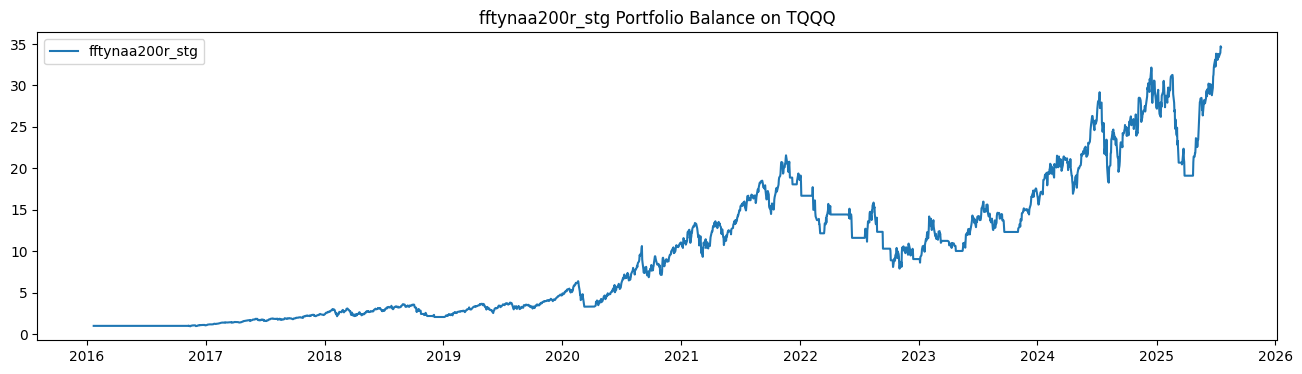

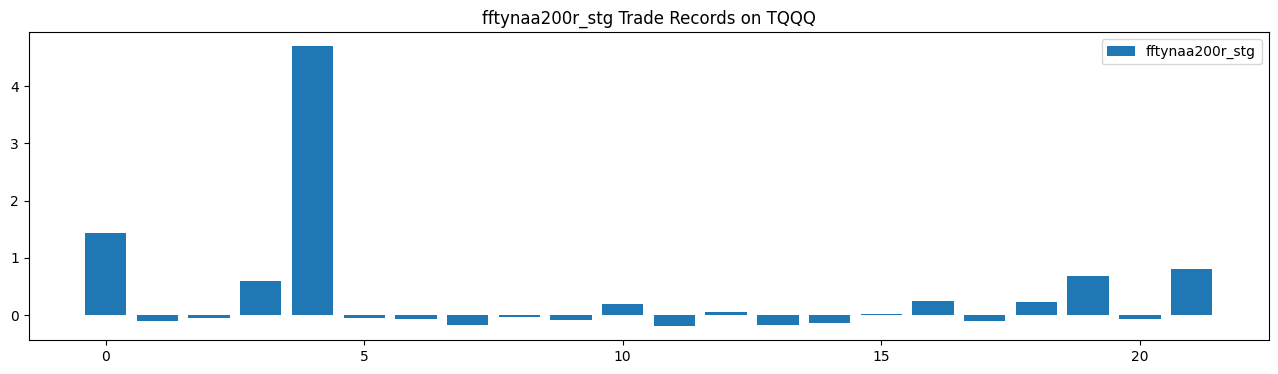

In [42]:
stg= ab.fftynaa200r_stg(naa200r_buy_threshold=15, naa200r_sell_threshold=30)
stg.run_strategy([ffty, naa200r],test_start, test_end)

stg_bt = ab.BackTest()
stg_bt.run_backtest(stg,ticker,test_start,test_end)

stg_bt.plot_balance()
stg_bt.plot_records()
stg_bt.performance_summary()
print(stg_bt.trade_records)

Index(['TQQQ', 'Weekday', 'Signal_x', 'BSignal', 'SSignal', 'Cash', 'Stock',
       'Total', 'Margin', 'Trade', 'Buy Price', 'Profit', 'FFTY',
       'FFTY-SMA200', 'FFTY_Signal', 'FFTY_TO_SMA200', 'NAA200R',
       'NAA200R-SMA20', 'NAA200R_Signal', 'Signal_y'],
      dtype='object')
Index(['FFTY', 'FFTY-SMA200', 'FFTY_Signal', 'FFTY_TO_SMA200', 'NAA200R',
       'NAA200R-SMA20', 'NAA200R_Signal', 'Signal'],
      dtype='object')


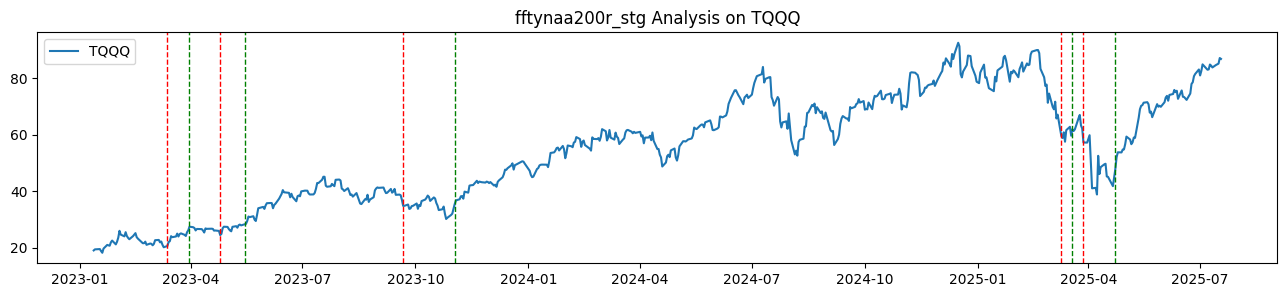

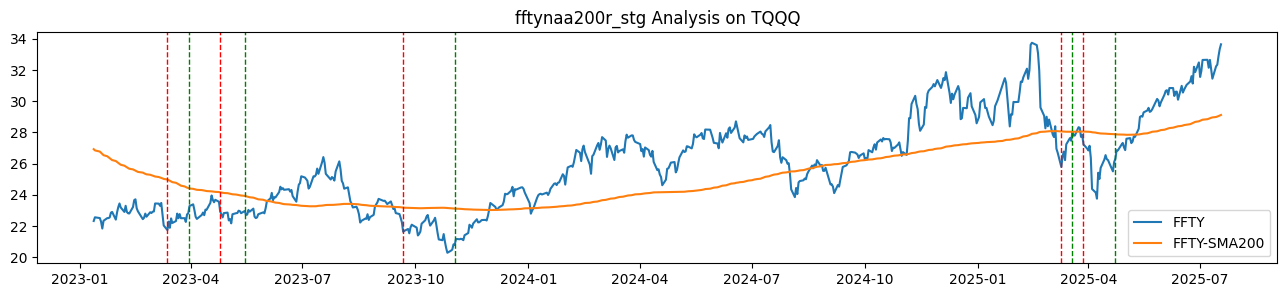

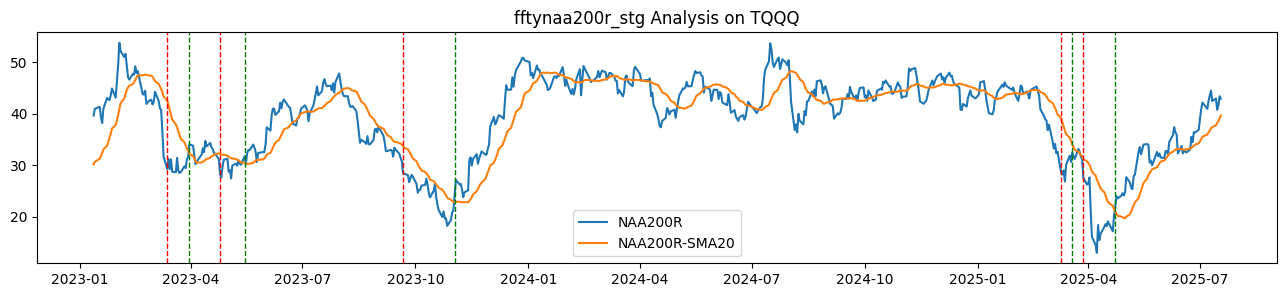

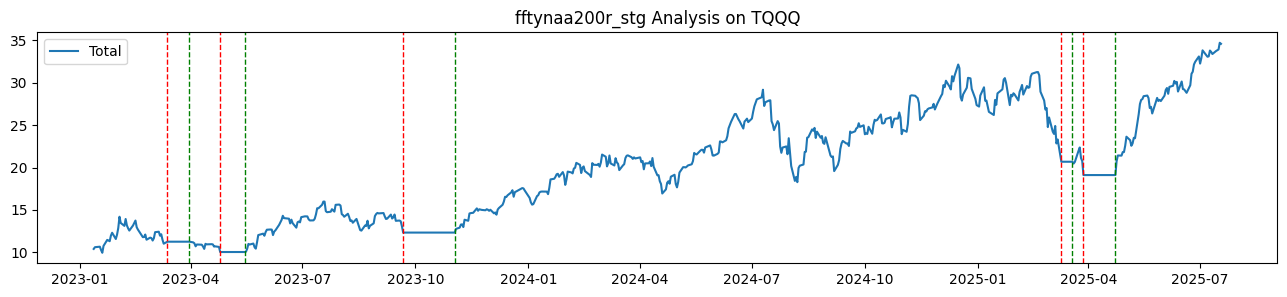

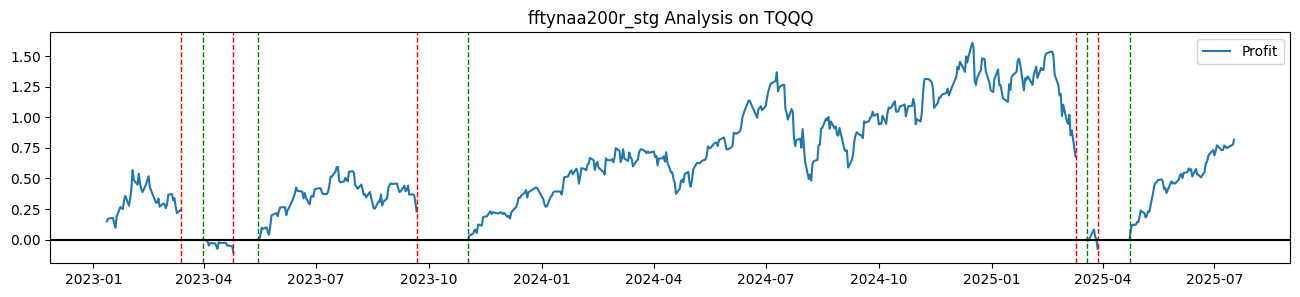

In [43]:
plot_start = dt.datetime(2023,1,12)
plot_end =   ed
print(stg_bt.joined_data.columns)
print(stg.joined_data.columns)
stg_bt.plot_joined_data([ticker.ticker], plot_start, plot_end)
stg_bt.plot_joined_data(['FFTY', 'FFTY-SMA200'], plot_start, plot_end)
stg_bt.plot_joined_data(['NAA200R', 'NAA200R-SMA20'], plot_start, plot_end)
stg_bt.plot_joined_data(['Total'], plot_start, plot_end)
stg_bt.plot_joined_data(['Profit'], plot_start, plot_end, ydash_low=0)
stg_bt.joined_data.to_csv('{}-{}.csv'.format(stg_bt.name, ticker.ticker))